In [1]:
%reload_ext autoreload
%autoreload 2
from collections.abc import Callable
import os
from pathlib import Path
import sys
from typing import Any, Literal

from matplotlib.axes import Axes
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from qecbench import TaskStats

import plot_utils

# Add parent directory to the path
sys.path.insert(0, os.path.abspath(".."))

from utils import get_csv_path

# Register learned decoders so they can be instantiated by `qecdec.decoders.create_decoder`.
import learned_decoders  # noqa: F401

%matplotlib inline
plt.rcParams.update({"pdf.fonttype": 42})
COLORS: list[str] = plt.rcParams["axes.prop_cycle"].by_key()["color"]

# Helper functions

In [2]:
def _label_fn(s: TaskStats) -> str:
    name = s.metadata.decoder_name
    return {
        "MemBP": "MemBP (IBM)",
        "LearnedDMemBP": "DMemBP (learned)",
        "RelayBP": "RelayBP (IBM)",
        "LearnedRelayBP": "RelayBP (learned)",
    }.get(name, name)


def _color_fn(s: TaskStats) -> str:
    name = s.metadata.decoder_name
    if name in ("MemBP", "LearnedDMemBP"):
        idx = 0
    elif name in ("RelayBP", "LearnedRelayBP"):
        idx = 1
    else:
        idx = 2
    return COLORS[idx % len(COLORS)]


def plot_fr_vs_iter(
    stats: list[TaskStats],
    error_rates: list[float],
    budget_list_fn: Callable[[TaskStats], list[int]],
    *,
    fr_mode: Literal["per_shot", "per_round"],
    iter_mode: Literal["max_iter", "avg_iter"],
    suptitle: str | None = None,
    save_at: str | Path | None = None,
):
    nrows, ncols = len(error_rates), 1
    fig, axs = plt.subplots(
        nrows,
        ncols,
        figsize=(10, 2 * nrows),
        squeeze=False,
        sharex=True,
        layout="constrained",
    )

    for row, error_rate in enumerate(error_rates):
        ax: Axes = axs[row, 0]
        plot_utils.plot_fr_vs_iter_contour_from_inferred(
            (s for s in stats if s.metadata.error_rate == error_rate),
            ax,
            budget_list_fn,
            fr_mode=fr_mode,
            iter_mode=iter_mode,
            label_fn=_label_fn,
            color_fn=_color_fn,
            linestyle=lambda s: "--" if "Learned" in s.metadata.decoder_name else "-",
            marker=lambda s: "^" if "Learned" in s.metadata.decoder_name else "o",
            mfc=lambda s: "none" if "Learned" in s.metadata.decoder_name else None,
            xscale="linear",
            yscale="log",
            show_legend=(row == 0),
        )
        ax.annotate(
            f"p = {error_rate:g}",
            xy=(0.98, 0.05),
            xycoords="axes fraction",
            verticalalignment="bottom",
            horizontalalignment="right",
            fontsize=plot_utils.LEGEND_FONTSIZE,
            fontweight="bold",
        )
        ax.yaxis.set_major_locator(
            ticker.LogLocator(base=10.0, subs=(1.0,), numticks=100)
        )

    ax: Axes = axs[0, 0]
    ax.set_xlim(left=0)
    fig.supxlabel("Avg. Iter", fontsize=plot_utils.SUPLABEL_FONTSIZE, fontweight="bold")
    fig.supylabel(
        "Failure Rate", fontsize=plot_utils.SUPLABEL_FONTSIZE, fontweight="bold"
    )
    if suptitle:
        fig.suptitle(suptitle, fontsize=plot_utils.SUPTITLE_FONTSIZE)
    if save_at:
        fig.savefig(save_at, bbox_inches="tight")
    plt.show()

# BB_144_12_12_Circuit, basis=Z, rounds=12, error_rate=0.001

Loaded 6 benchmark entries


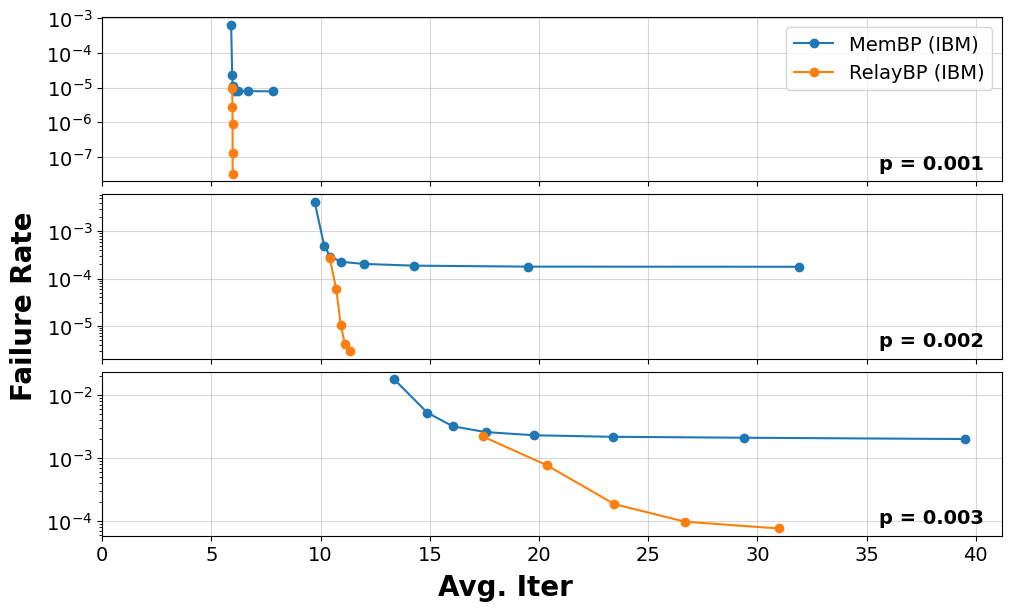

In [3]:
circuit_name = "BB_144_12_12_Circuit"
circuit_params = {"basis": "Z", "rounds": 12}
error_rates = [0.001, 0.002, 0.003]

membp = {"max_iter": 20000, "gamma": 0.2}
relaybp = {
    "gamma0": 0.2,
    "gamma_dist_interval": (-0.19806670996164882, 0.6200937872049607),
    "num_relays": 500,
    "pre_iter": 50,
    "max_iter_per_relay": 50,
    "stop_nconv": 1,
}

stats = [
    *plot_utils.load_stats(
        get_csv_path(circuit_name, circuit_params, "MemBP"),
        error_rates=error_rates,
        decoder_fixed_params=membp,
    ),
    *plot_utils.load_stats(
        get_csv_path(circuit_name, circuit_params, "RelayBP"),
        error_rates=error_rates,
        decoder_fixed_params=relaybp,
    ),
]
print(f"Loaded {len(stats)} benchmark entries")


def budget_list_fn(s: TaskStats) -> list[int]:
    decoder_name = s.metadata.decoder_name
    error_rate = s.metadata.error_rate
    if decoder_name == "MemBP":
        stop = {0.001: 20000, 0.002: 10000, 0.003: 1000}[error_rate]
        budget_list = sorted(set(int(x) for x in np.round(np.geomspace(20, stop, 8))))
    elif decoder_name == "RelayBP":
        stop = {0.001: 64, 0.002: 500, 0.003: 500}[error_rate]
        num_relays_list = sorted(
            set(int(x) for x in np.round(np.geomspace(1, stop, 5)))
        )
        budget_list = [50 * (r + 1) for r in num_relays_list]
    else:
        raise NotImplementedError
    return budget_list


plot_fr_vs_iter(
    stats,
    error_rates,
    budget_list_fn,
    fr_mode="per_round",
    iter_mode="avg_iter",
    save_at="fr_vs_iter-BB_Circuit-nconv=1.pdf",
)


# RotatedSurfaceCode_Circuit, basis=Z, d=11, rounds=11, error_rate=0.001

Loaded 6 benchmark entries


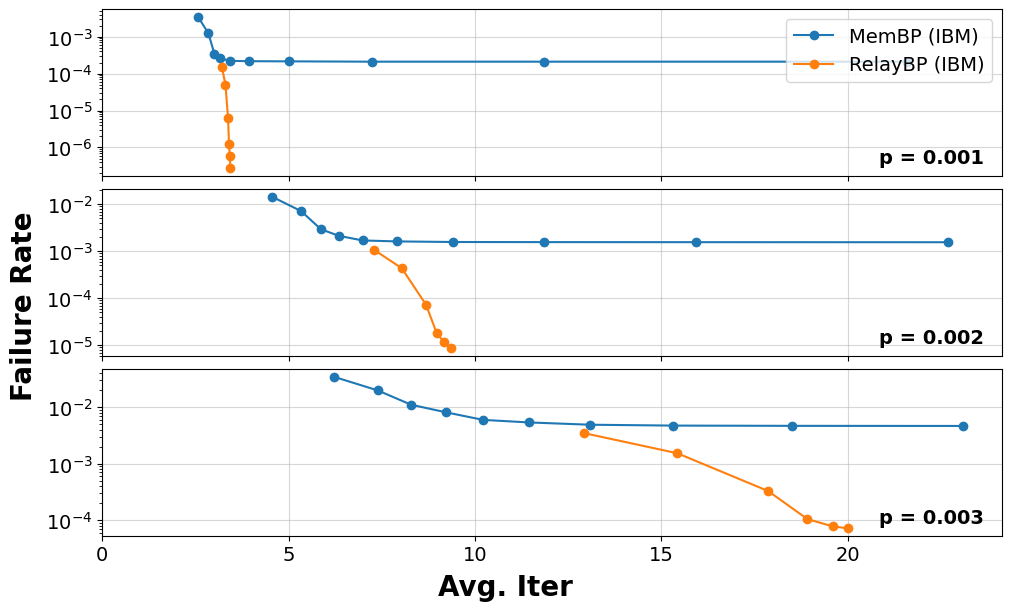

In [4]:
circuit_name = "RotatedSurfaceCode_Circuit"
circuit_params = {"basis": "Z", "d": 11, "rounds": 11}
error_rates = [0.001, 0.002, 0.003]

membp = {"max_iter": 15050, "gamma": 0.55}
relaybp = {
    "gamma0": 0.55,
    "gamma_dist_interval": (-0.2944735403909491, 0.9444054073490704),
    "num_relays": 300,
    "pre_iter": 50,
    "max_iter_per_relay": 50,
    "stop_nconv": 1,
}

stats = [
    *plot_utils.load_stats(
        get_csv_path(circuit_name, circuit_params, "MemBP"),
        error_rates=error_rates,
        decoder_fixed_params=membp,
    ),
    *plot_utils.load_stats(
        get_csv_path(circuit_name, circuit_params, "RelayBP"),
        error_rates=error_rates,
        decoder_fixed_params=relaybp,
    ),
]
print(f"Loaded {len(stats)} benchmark entries")


def budget_list_fn(s: TaskStats) -> list[int]:
    decoder_name = s.metadata.decoder_name
    error_rate = s.metadata.error_rate
    if decoder_name == "MemBP":
        stop = {0.001: 8000, 0.002: 1000, 0.003: 300}[error_rate]
        budget_list = sorted(set(int(x) for x in np.round(np.geomspace(10, stop, 10))))
    elif decoder_name == "RelayBP":
        num_relays_list = sorted(set(int(x) for x in np.round(np.geomspace(1, 300, 6))))
        budget_list = [50 * (r + 1) for r in num_relays_list]
    else:
        raise NotImplementedError
    return budget_list


plot_fr_vs_iter(
    stats,
    error_rates,
    budget_list_fn,
    fr_mode="per_round",
    iter_mode="avg_iter",
    save_at="fr_vs_iter-RSC_Circuit-nconv=1.pdf",
)


# RotatedSurfaceCode_Phenom, basis=Z, d=11, rounds=11, error_rate=0.005

Loaded 12 benchmark entries


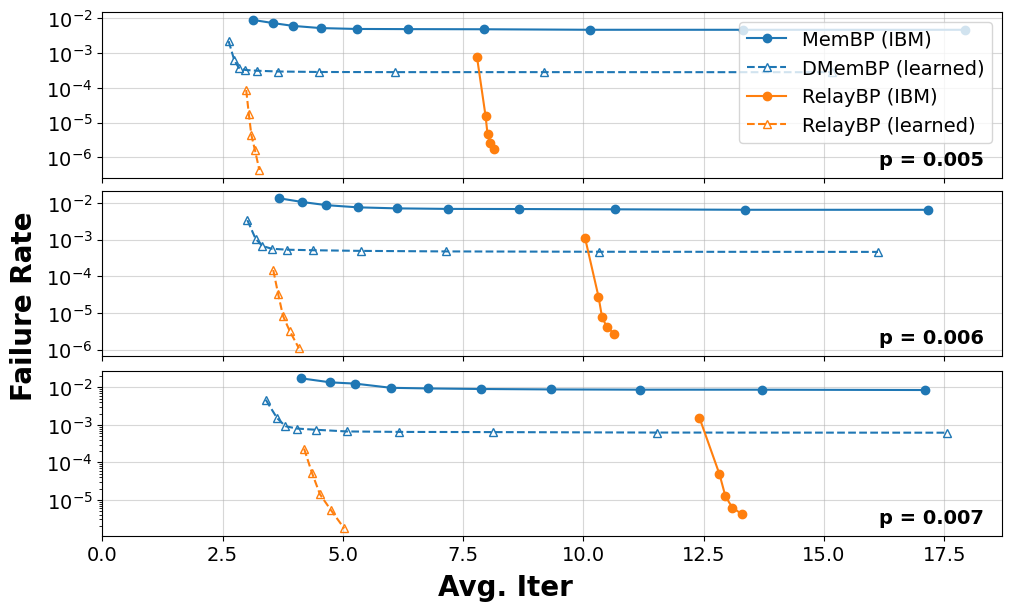

In [5]:
circuit_name = "RotatedSurfaceCode_Phenom"
circuit_params = {"basis": "Z", "d": 11, "rounds": 11}
error_rates = [0.005, 0.006, 0.007]
ckpt = "torchdecoder/runs/RotatedSurfaceCode_Phenom/basis=Z_d=11_rounds=11/LearnedDMemBP/run_0/checkpoints/best_model.ckpt"

membp = {"max_iter": 15050, "gamma": 0.65}
learned_dmembp = {"max_iter": 15050, "ckpt_rel_path": ckpt}
relaybp = {
    "gamma0": 0.65,
    "gamma_dist_interval": (-0.2241259276391633, 0.5608805426310253),
    "num_relays": 300,
    "pre_iter": 50,
    "max_iter_per_relay": 50,
    "stop_nconv": 1,
}
learned_relaybp = {
    "ckpt_rel_path": ckpt,
    "gamma_dist_interval": (-0.2241259276391633, 0.5608805426310253),
    "num_relays": 300,
    "pre_iter": 50,
    "max_iter_per_relay": 50,
    "stop_nconv": 1,
}

stats = [
    *plot_utils.load_stats(
        get_csv_path(circuit_name, circuit_params, "MemBP"),
        error_rates=error_rates,
        decoder_fixed_params=membp,
    ),
    *plot_utils.load_stats(
        get_csv_path(circuit_name, circuit_params, "LearnedDMemBP"),
        error_rates=error_rates,
        decoder_fixed_params=learned_dmembp,
    ),
    *plot_utils.load_stats(
        get_csv_path(circuit_name, circuit_params, "RelayBP"),
        error_rates=error_rates,
        decoder_fixed_params=relaybp,
    ),
    *plot_utils.load_stats(
        get_csv_path(circuit_name, circuit_params, "LearnedRelayBP"),
        error_rates=error_rates,
        decoder_fixed_params=learned_relaybp,
    ),
]
print(f"Loaded {len(stats)} benchmark entries")


def budget_list_fn(s: TaskStats) -> list[int]:
    decoder_name = s.metadata.decoder_name
    error_rate = s.metadata.error_rate
    if decoder_name in ["MemBP"]:
        stop = {0.005: 300, 0.006: 200, 0.007: 150}[error_rate]
        budget_list = sorted(set(int(x) for x in np.round(np.geomspace(10, stop, 10))))
    elif decoder_name in ["LearnedDMemBP"]:
        stop = {0.005: 4000, 0.006: 2500, 0.007: 2000}[error_rate]
        budget_list = sorted(set(int(x) for x in np.round(np.geomspace(10, stop, 10))))
    elif decoder_name in ["RelayBP", "LearnedRelayBP"]:
        num_relays_list = sorted(set(int(x) for x in np.round(np.geomspace(1, 300, 5))))
        budget_list = [50 * (r + 1) for r in num_relays_list]
    else:
        raise NotImplementedError
    return budget_list


plot_fr_vs_iter(
    stats,
    error_rates,
    budget_list_fn,
    fr_mode="per_round",
    iter_mode="avg_iter",
    save_at="fr_vs_iter-RSC_Phenom-nconv=1.pdf",
)
